In [ ]:

!pip install kaggle

In [ ]:
import os
os.environ['KAGGLE_USERNAME']='khushitomar14'
os.environ['KAGGLE_KEY']='KGAT_7da39dc18559b1ddd442b454be459824'

In [ ]:
!kaggle datasets download -d leonbora/analytics-vidhya-loan-prediction
!unzip analytics-vidhya-loan-prediction.zip

Dataset URL: https://www.kaggle.com/datasets/leonbora/analytics-vidhya-loan-prediction
License(s): unknown
analytics-vidhya-loan-prediction.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  analytics-vidhya-loan-prediction.zip
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: test.csv                
  inflating: train.csv               


LOADING DATASET


In [ ]:
import pandas as pd
df= pd.read_csv("train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


------PERFORMING EDA-------

In [ ]:
# shape
print(df.shape)

# columns name
print(df.columns)

# dataset infor we will see categorical and numerical features
print(df.info())

# check missing values
print(df.isnull().sum())

#basic statistics
df.describe()



(614, 13)
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Are

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


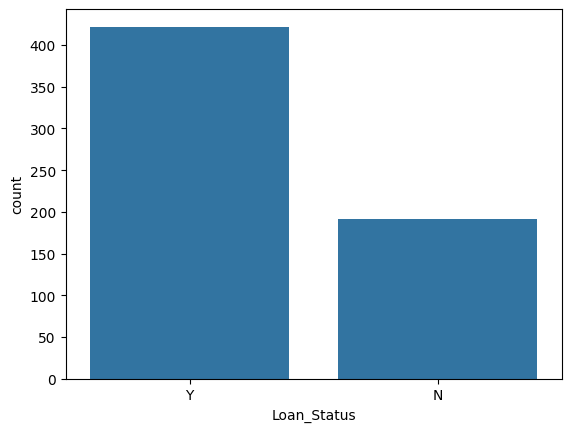

In [ ]:
# how many loans were approved and rejected

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Loan_Status", data=df)
plt.show()


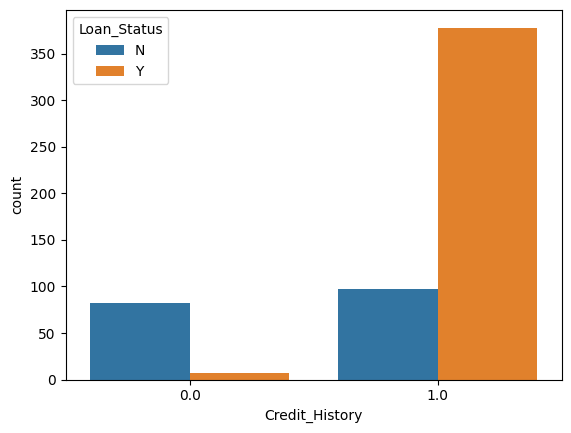

In [ ]:
# credit history vs loan approval
sns.countplot(x="Credit_History", hue="Loan_Status", data=df)
plt.show()

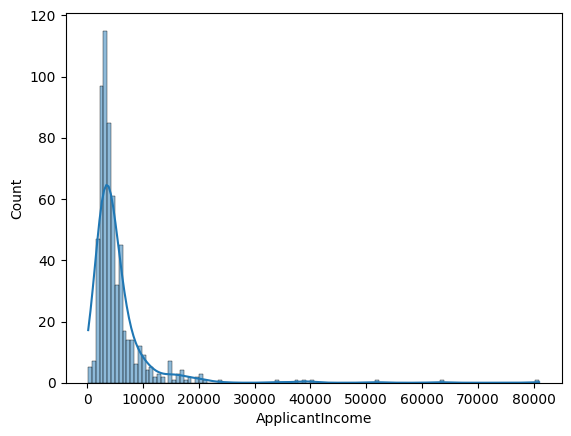

In [ ]:
#income distribution
sns.histplot(df["ApplicantIncome"], kde=True)
plt.show()

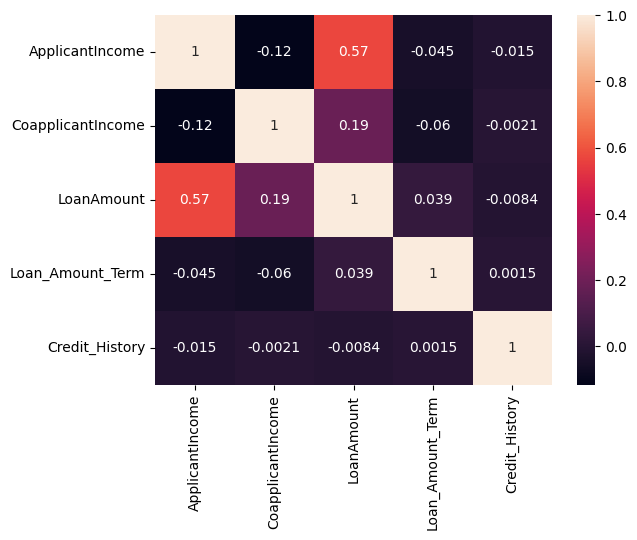

In [ ]:
#correlation between numerical features
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

----DATA PREPROCESSING----

In [ ]:
df.isnull().sum()
#fill missing values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [ ]:
# convert categorical data into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])

# fixing special columns. dependent feature has a value +3

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [ ]:
#dropping unnecessary column
df.drop('Loan_ID', axis=1, inplace=True)

In [ ]:
#feature engineering
#making a new feature of total income and dropping olders.
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.drop(['ApplicantIncome', 'CoapplicantIncome'], axis=1, inplace=True)


In [ ]:
#train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X,y,test_size= 0.2, random_state= 42
)

#feature scaling
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

--------MODEL TRAINING-----

In [ ]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#making predictions
y_pred= model.predict(X_test)

In [ ]:
#checking accuracy
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.7804878048780488


In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print(cm)

# classification report
from sklearn.metrics import classification_report
classif=classification_report(y_test, y_pred)
print(classif)

[[18 25]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



---using random forest----

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.7804878048780488
              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



In [ ]:
X.columns
#len(X.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'TotalIncome', 'LoanAmount_per_Income'],
      dtype='object')

In [ ]:
#testing with custom data
import numpy as np
sample = pd.DataFrame([{
    'Gender': 1,
    'Married': 1,
    'Dependents': 0,
    'Education': 1,
    'Self_Employed': 0,
    'LoanAmount': 200,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,
    'Property_Area': 2,
    'TotalIncome': 2000,
    'LoanAmount_per_Income': 300/2000
}])

sample_scaled = scaler.transform(sample)

prediction = rf.predict(sample_scaled)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Rejected


-------SAVING MODEL-------

In [ ]:
import pickle

pickle.dump(rf, open("loan_model.pkl", "wb"))